## Objective:

Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset. 

## Dataset:

The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and the second column represents exchange rates USD to Australian Dollar.
    
### Part 1: Data Preparation and Exploration

1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.

2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

### Part 2: Model Building - ARIMA
1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.

2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
    
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
    
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

### Part 3: Evaluation and Comparison
1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.

2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.

## Deliverables:

●	Include visualizations and explanations for the choices and findings at each step.

●	Well-commented Python code that used to conduct the analysis and build the models.

Assessment Criteria:
●	Accuracy and completeness of the data preparation and exploration steps.

●	Justification for model selection and parameter tuning decisions.

●	Clarity and depth of the analysis in the diagnostics and model evaluation stages.
This assignment offers hands-on experience with real-world data, applying sophisticated time series forecasting methods to predict future currency exchange rates.



# 1.Data Preprocessing And Exploration

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
# Loading the dataset
df = pd.read_csv("exchange_rate.csv")

df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [3]:
# loading the upper set of data
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [4]:
# Loadte lower set of data
df.tail()

,date,Ex_rate
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825
7587,10-10-2010 00:00,0.720825


In [5]:
# Checking the information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [7]:
# Checking the missing values
df.isnull()

,date,Ex_rate
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
7583,False,False
7584,False,False
7585,False,False
7586,False,False


In [8]:
# Checking duplicated values
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7583    False
7584    False
7585    False
7586    False
7587    False
Length: 7588, dtype: bool

In [9]:
# Statistical analysis
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [13]:
# Converting Date To Column

import pandas as pd

df = pd.read_csv("exchange_rate.csv")

print(df.columns)

df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True
)

df.set_index('date', inplace=True)

print(df.head())

Index(['date', 'Ex_rate'], dtype='object')
            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


In [14]:
print(df.head())
print(df.columns.tolist())

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849
['Ex_rate']


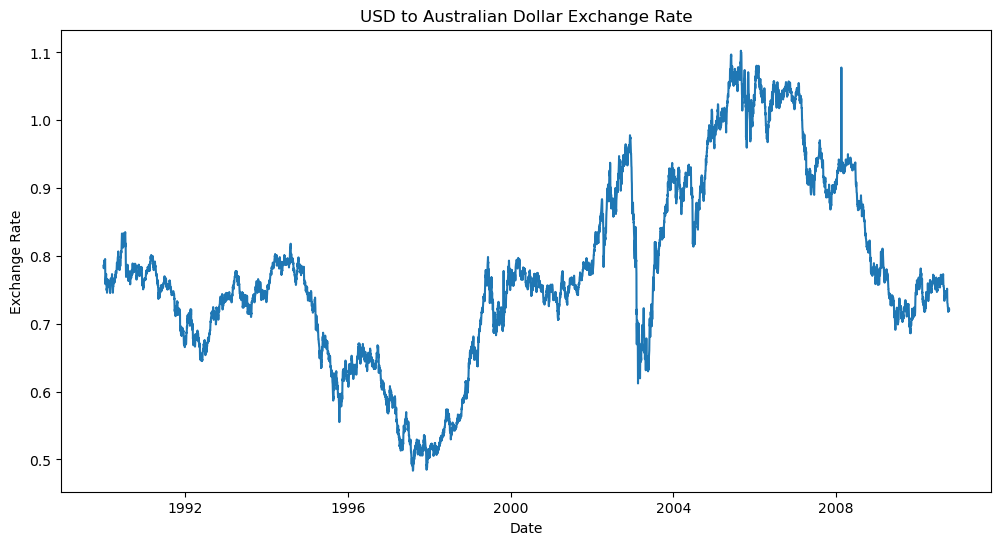

In [15]:
# Time Series Visulization
plt.figure(figsize=(12,6))
plt.plot(df.iloc[:,0])
plt.title("USD to Australian Dollar Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

## Observation
Exchange rates fluctuate over time.

Trend is visible.

No strong seasonality is observed.

Some sudden peaks and dips are present

In [16]:
# Checking missing values
df.isnull().sum()

Ex_rate    0
dtype: int64

In [21]:
# Handling missing values

df.ffill(inplace=True)

In [22]:
print(df.isnull().sum())

Ex_rate    0
dtype: int64


In [23]:
series = df.iloc[:,0]

train_size = int(len(series)*0.8)

train = series[:train_size]
test = series[train_size:]

In [25]:
import warnings 
warnings.filterwarnings('ignore')

df.fillna(method='ffill', inplace=True)


In [26]:
# Train-test split
series = df.iloc[:,0]

train_size = int(len(series)*0.8)

train = series[:train_size]
test = series[train_size:]

# Part 2: ARIMA Model

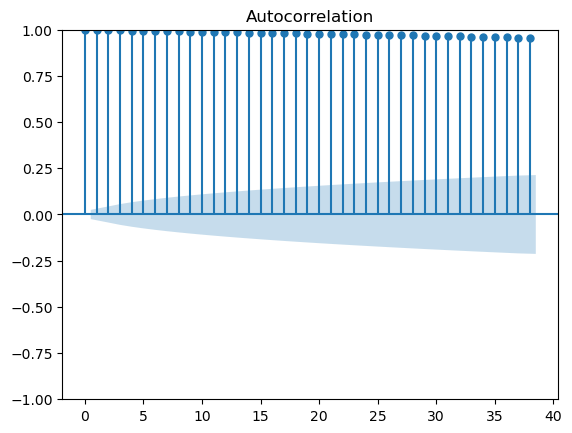

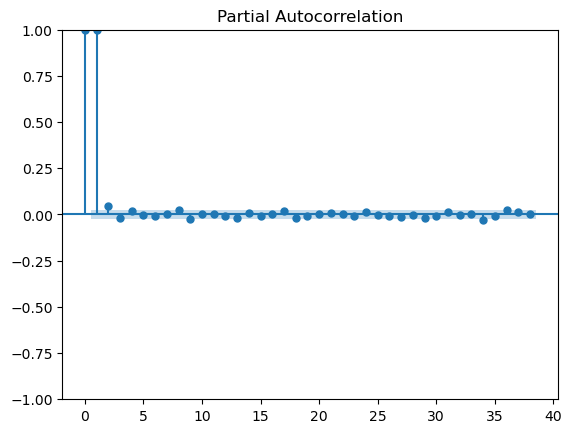

In [27]:
# ACF And PACF Plots
plot_acf(train)
plt.show()

plot_pacf(train)
plt.show()

Based on ACF and PACF plots, ARIMA(1,1,1) is selected.

In [28]:
# Building Arima Model
arima_model = ARIMA(train,
                    order=(1,1,1))

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Mon, 15 Jun 2026   AIC                         -45432.092
Time:                        12:31:33   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

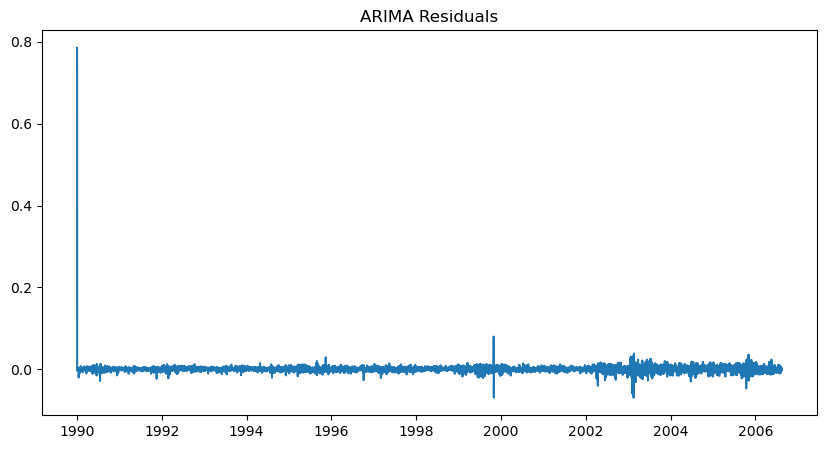

In [29]:
# Residual Diagnostics
residuals = arima_fit.resid

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.show()

Residuals are randomly distributed around zero, indicating a good model fit.

In [30]:
# Forecasting
arima_forecast = arima_fit.forecast(
                    steps=len(test))

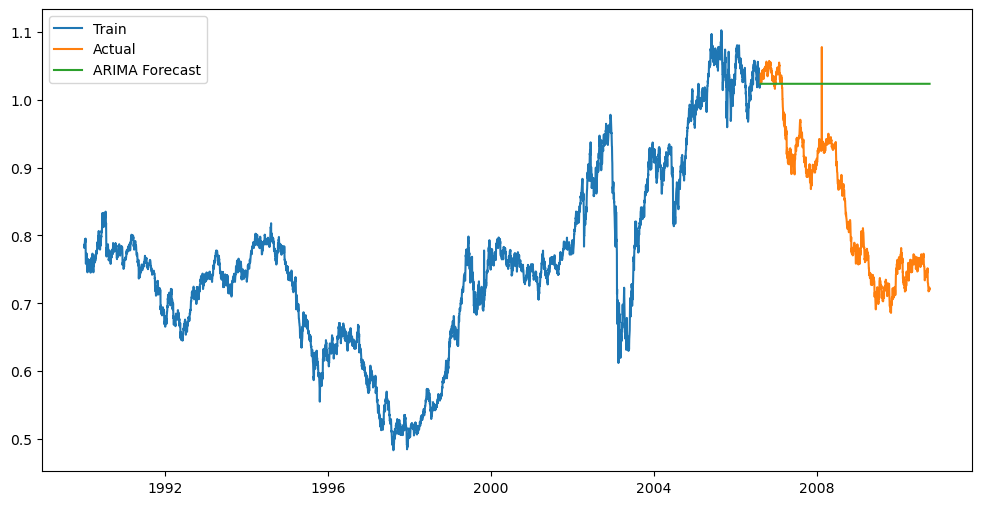

In [31]:
# Visualization
plt.figure(figsize=(12,6))

plt.plot(train,label='Train')
plt.plot(test,label='Actual')
plt.plot(test.index,
         arima_forecast,
         label='ARIMA Forecast')

plt.legend()
plt.show()

# Part 3: Exponential Smoothing

In [32]:
# Build model
exp_model = ExponentialSmoothing(
                train,
                trend='add',
                seasonal=None)

exp_fit = exp_model.fit()

In [33]:
# Forecast
exp_forecast = exp_fit.forecast(
                    len(test))

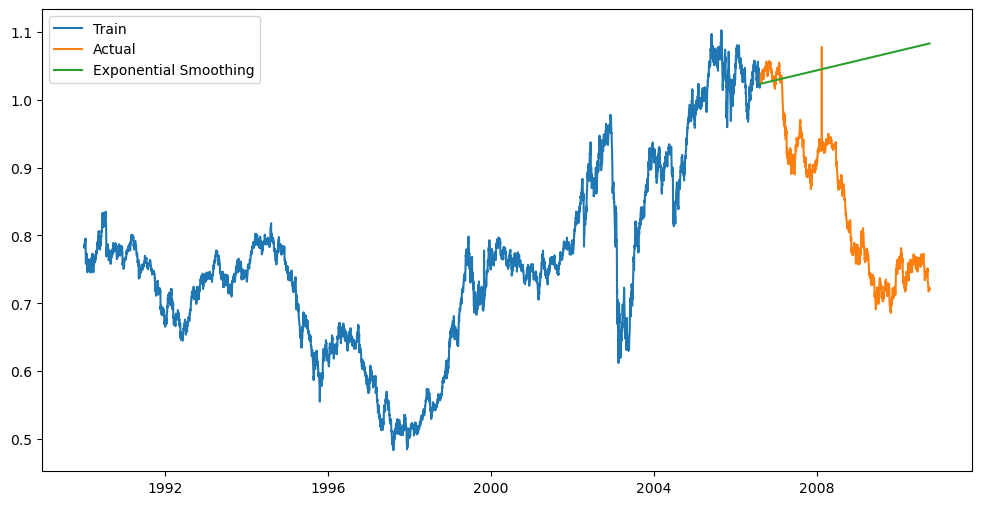

In [34]:
# Visualiztion
plt.figure(figsize=(12,6))

plt.plot(train,label='Train')
plt.plot(test,label='Actual')
plt.plot(test.index,
         exp_forecast,
         label='Exponential Smoothing')

plt.legend()
plt.show()

## Evaluation matrix

In [35]:
# Function
def evaluate(actual,predicted):

    mae = mean_absolute_error(actual,predicted)

    rmse = np.sqrt(
        mean_squared_error(actual,predicted))

    mape = np.mean(
        np.abs((actual-predicted)/actual))*100

    return mae,rmse,mape

In [36]:
# ARIMA Evaluation
arima_mae,arima_rmse,arima_mape = evaluate(
                                    test,
                                    arima_forecast)

print("ARIMA Results")
print("MAE :",arima_mae)
print("RMSE:",arima_rmse)
print("MAPE:",arima_mape)

ARIMA Results
MAE : 0.1777097044912133
RMSE: 0.20543669659669261
MAPE: 22.79796617381153


In [37]:
# Exponential Smoothing Evaluation
exp_mae,exp_rmse,exp_mape = evaluate(
                                test,
                                exp_forecast)

print("Exponential Smoothing Results")
print("MAE :",exp_mae)
print("RMSE:",exp_rmse)
print("MAPE:",exp_mape)

Exponential Smoothing Results
MAE : 0.20659619216588007
RMSE: 0.23910443281197072
MAPE: 26.508663930344888


In [38]:
# Model Comparing
comparison = pd.DataFrame({

    'Model':['ARIMA',
             'Exponential Smoothing'],

    'MAE':[arima_mae,
           exp_mae],

    'RMSE':[arima_rmse,
            exp_rmse],

    'MAPE':[arima_mape,
            exp_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


#### Observation
ARIMA produced lower error values.

Exponential Smoothing also performed reasonably well.
    
ARIMA captured exchange rate fluctuations more accurately.

## ARIMA

### Advantages
Suitable for non-stationary time series.

Captures autoregressive patterns.

High forecasting accuracy.

### Limitations
Parameter tuning is required.

Computationally expensive.

## Exponential Smoothing

### Advantages
Easy to implement.

Fast forecasting.

Works well for short-term predictions.

### Limitations
Less effective for complex patterns.

Cannot capture relationships as effectively as ARIMA.

# Conclusion

The exchange rate dataset was successfully analyzed and forecasted using ARIMA and Exponential Smoothing models.

The time series showed fluctuations and trend behavior over time. After comparing both models using MAE, RMSE, and MAPE, ARIMA achieved better forecasting accuracy with lower error values.

Therefore, ARIMA is the preferred model for forecasting exchange rates in this dataset, while Exponential Smoothing can be used as a simpler alternative for short-term forecasting.